In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('titanic_Daniela.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [4]:
print(df.shape)

(891, 12)


In [5]:
print("---")

---


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.drop(columns=['Cabin'], inplace=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [10]:
median_age_female = df[df['Sex'] == 'female']['Age'].median()
df.loc[(df['Sex'] == 'female') & (df['Age'].isnull()), 'Age'] = median_age_female

In [11]:
print(median_age_female)

27.0


In [12]:
median_age_male = df[df['Sex'] == 'male']['Age'].median()
df.loc[(df['Sex'] == 'male') & (df['Age'].isnull()), 'Age'] = median_age_male
print(median_age_male)

29.0


In [13]:
most_common_port = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_common_port)

In [14]:
# ── FEATURE ENGINEERING ──────────────────────────────────────

# 1. FareClass (text label) + FareClassNum (numeric for correlation)
bins = [0, 15, 50, df['Fare'].max() + 1]
labels = ['Cheap', 'Medium', 'Rich']

df['FareClass'] = pd.cut(
    df['Fare'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

fare_class_map = {'Cheap': 0, 'Medium': 1, 'Rich': 2}
df['FareClassNum'] = df['FareClass'].map(fare_class_map)

# 2. Sex_num (numeric gender for correlation)
df['Sex_num'] = df['Sex'].map({'female': 1, 'male': 0})

# 3. FamilySize + IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 4. AgeGroup (text label for Q4 chart)
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 40, 60, 80],
    labels=['Child (0-12)', 'Teenager (13-18)', 'Adult (19-40)',
            'Old Adult (41-60)', 'Elder (61-80)']
)

# Verify all new columns exist
print("New columns added:")
print(df[['Fare','FareClass','FareClassNum',
          'Sex','Sex_num',
          'FamilySize','IsAlone',
          'Age','AgeGroup']].head(5))

New columns added:
      Fare FareClass FareClassNum     Sex  Sex_num  FamilySize  IsAlone   Age  \
0   7.2500     Cheap            0    male        0           2        0  22.0   
1  71.2833      Rich            2  female        1           2        0  38.0   
2   7.9250     Cheap            0  female        1           1        1  26.0   
3  53.1000      Rich            2  female        1           2        0  35.0   
4   8.0500     Cheap            0    male        0           1        1  35.0   

        AgeGroup  
0  Adult (19-40)  
1  Adult (19-40)  
2  Adult (19-40)  
3  Adult (19-40)  
4  Adult (19-40)  


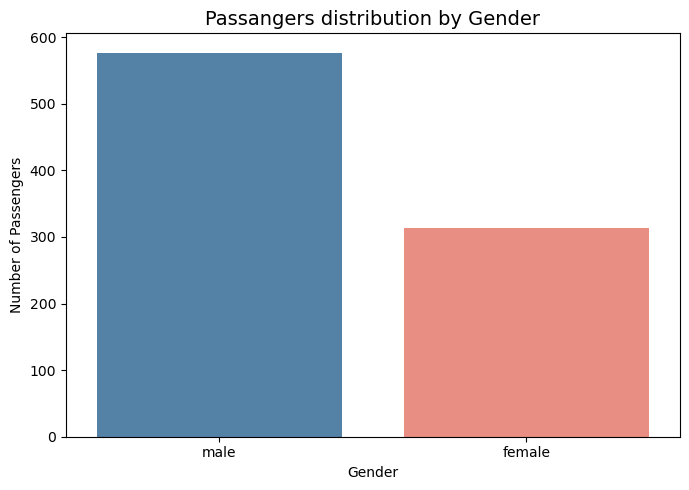

In [15]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df, 
    x='Sex',
    hue='Sex', 
    palette={'male': 'steelblue', 'female': 'salmon'},
    legend=False
    )

plt.title('Passangers distribution by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.tight_layout()
plt.show()

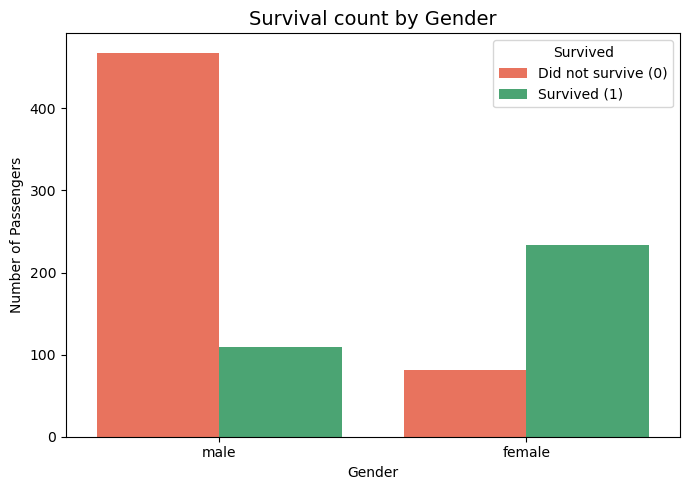

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Sex',
    hue='Survived',
    palette={0: 'tomato', 1: 'mediumseagreen'},
    )

plt.title('Survival count by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['Did not survive (0)', 'Survived (1)'])

plt.tight_layout()
plt.show()

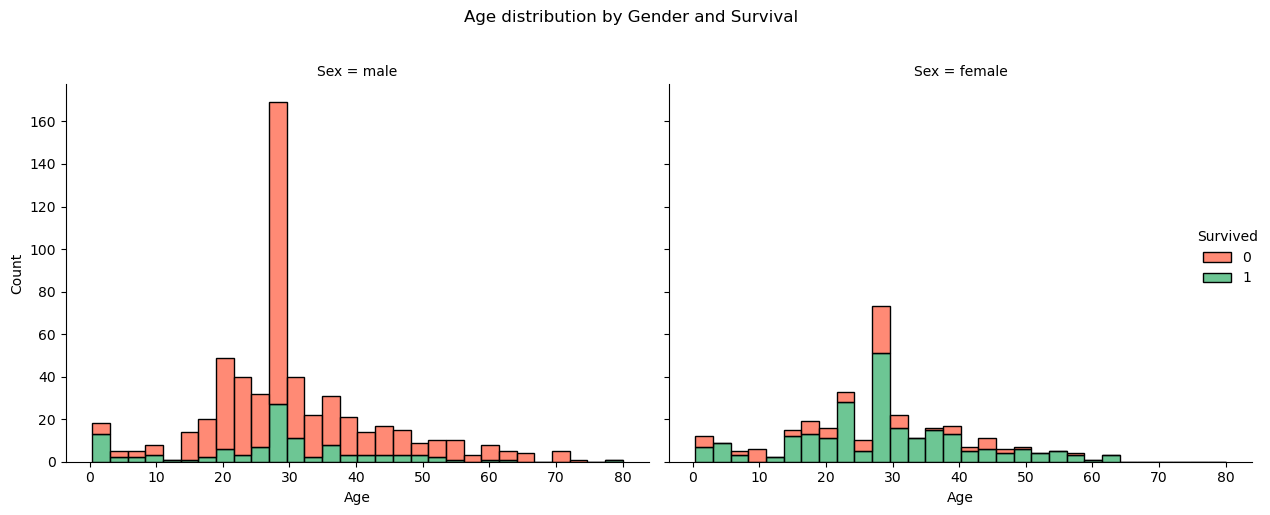

In [17]:
g = sns.displot(
    data=df,
    x='Age',
    col='Sex',
    hue='Survived',
    multiple='stack',
    palette={0: 'tomato', 1: 'mediumseagreen'},
    height=5,
    aspect=1.2
)

g.figure.suptitle('Age distribution by Gender and Survival', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# --- New Column 1: Sex_num ---
# Convert text gender to number so it can enter the correlation matrix
# female = 1, male = 0
# Why female=1? Because higher value = more likely to survive (positive correlation)

df['Sex_num'] = df['Sex'].map({'female': 1, 'male': 0})

print("Sex_num sample:")
print(df[['Sex', 'Sex_num']].head(6))

# --- New Column 2: FamilySize ---
# Total number of people in the passenger's family group on board
# Formula: siblings/spouses + parents/children + yourself

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print("\nFamilySize distribution:")
print(df['FamilySize'].value_counts().sort_index())

# --- New Column 3: IsAlone ---
# Binary flag: was this passenger traveling alone?
# 1 = alone (FamilySize == 1), 0 = with family

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("\nIsAlone distribution:")
print(df['IsAlone'].value_counts())
print()
print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(10))

Sex_num sample:
      Sex  Sex_num
0    male        0
1  female        1
2  female        1
3  female        1
4    male        0
5    male        0

FamilySize distribution:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

IsAlone distribution:
IsAlone
1    537
0    354
Name: count, dtype: int64

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0


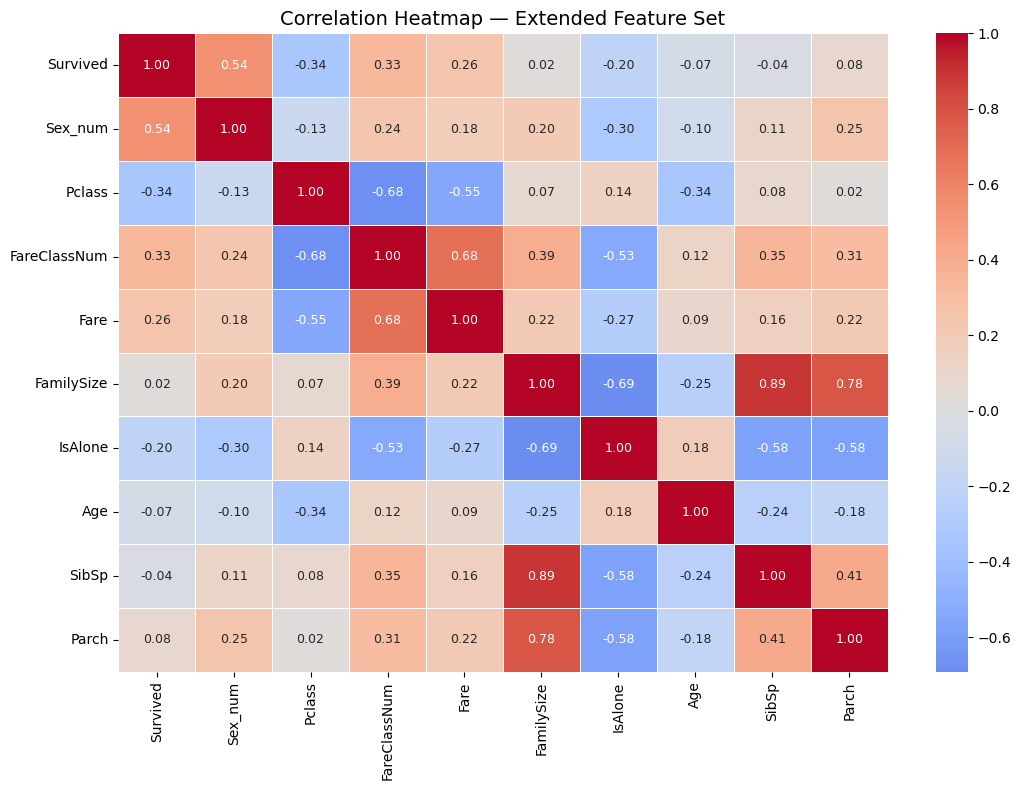

In [19]:
cols_for_corr = [
    'Survived',
    'Sex_num',      # NEW - strongest predictor
    'Pclass',
    'FareClassNum',
    'Fare',
    'FamilySize',   # NEW - combined family signal
    'IsAlone',      # NEW - solo traveler flag
    'Age',
    'SibSp',
    'Parch'
]

corr_mtx = df[cols_for_corr].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr_mtx,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 9}
)

plt.title('Correlation Heatmap — Extended Feature Set', fontsize=14)
plt.tight_layout()
plt.show()

Survival rate by passenger class (%):
   Pclass  SurvivalRate
0       1     62.962963
1       2     47.282609
2       3     24.236253


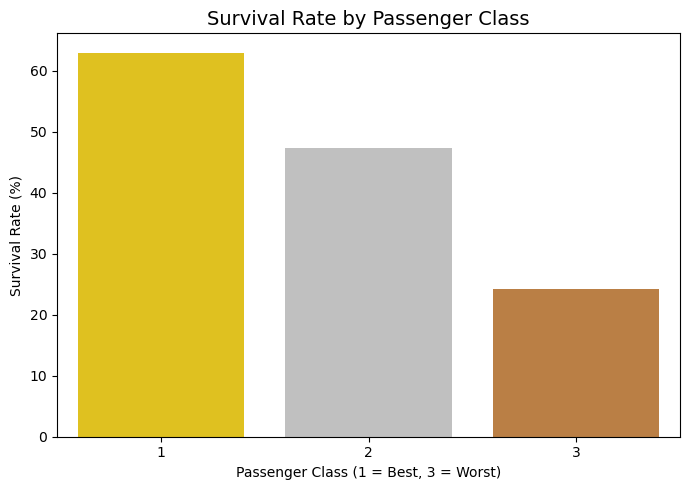

In [20]:
# Research Question 1:
# Does passenger class affect the survival rate?

survival_by_class = (
    df.groupby('Pclass')['Survived']
      .mean()
      .mul(100)
      .reset_index(name='SurvivalRate')
)

print("Survival rate by passenger class (%):")
print(survival_by_class)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=survival_by_class,
    x='Pclass',
    y='SurvivalRate',
    hue='Pclass',
    palette={1: 'gold', 2: 'silver', 3: '#cd7f32'},
    legend=False
)

plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Passenger Class (1 = Best, 3 = Worst)')
plt.ylabel('Survival Rate (%)')

plt.tight_layout()
plt.show()

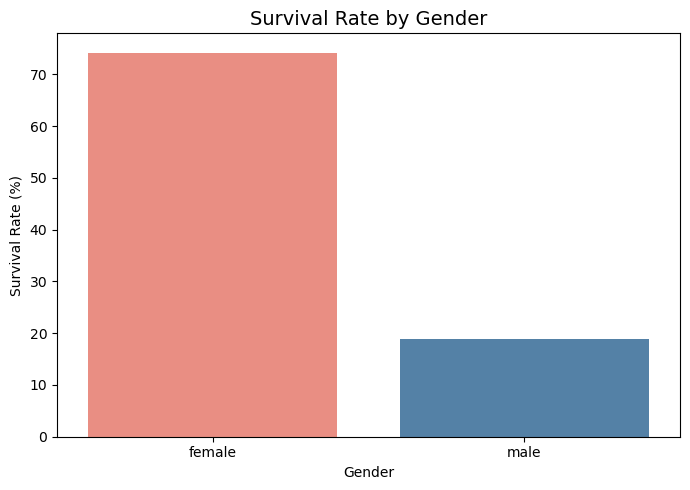

In [21]:
# Research Question 2:
# Does gender affect the survival rate?

survival_by_gender = (
    df.groupby('Sex')['Survived']
      .mean()
      .mul(100)
      .reset_index(name='SurvivalRate')
)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=survival_by_gender,
    x='Sex',
    y='SurvivalRate',
    hue='Sex',
    palette={'male': 'steelblue', 'female': 'salmon'},
    legend=False
)

plt.title('Survival Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Survival Rate (%)')

plt.tight_layout()
plt.show()

Average fare by survival status:
   Survived  AverageFare
0         0        22.12
1         1        48.40


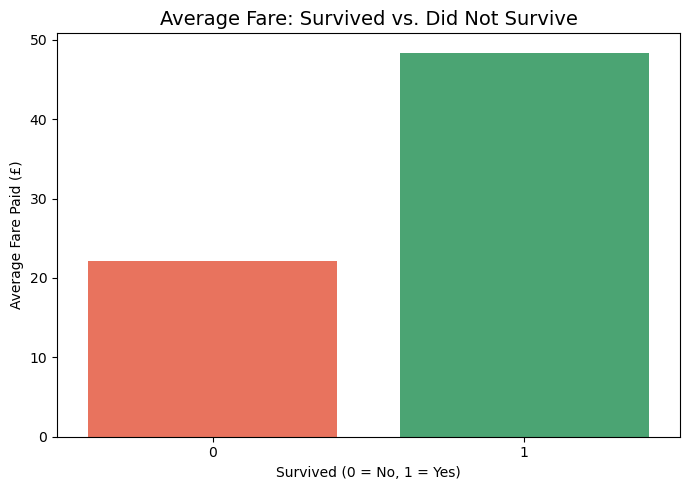

In [22]:
# Q3 - Version 2: Pre-aggregated Barplot (best practice, consistent with Q2)

fare_summary = (
    df.groupby('Survived')['Fare']
      .mean()
      .round(2)
      .reset_index(name='AverageFare')
)

print("Average fare by survival status:")
print(fare_summary)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=fare_summary,
    x='Survived',
    y='AverageFare',
    hue='Survived',
    palette={0: 'tomato', 1: 'mediumseagreen'},
    legend=False,
    errorbar=None
)

plt.title('Average Fare: Survived vs. Did Not Survive', fontsize=14)
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Average Fare Paid (£)')

plt.tight_layout()
plt.show()

In [23]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,40,60,80],
                         labels=['Copil (0-12)','Adolescent (13-18)','Adult (19-40)','Matur (41-60)','Vârstnic (61-80)'])
df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100 

AgeGroup
Copil (0-12)          57.971014
Adolescent (13-18)    42.857143
Adult (19-40)         36.046512
Matur (41-60)         39.062500
Vârstnic (61-80)      22.727273
Name: Survived, dtype: float64

In [24]:
# --- New Column 1: Sex_num ---
# Convert text gender to number so it can enter the correlation matrix
# female = 1, male = 0
# Why female=1? Because higher value = more likely to survive (positive correlation)

df['Sex_num'] = df['Sex'].map({'female': 1, 'male': 0})

print("Sex_num sample:")
print(df[['Sex', 'Sex_num']].head(6))

# --- New Column 2: FamilySize ---
# Total number of people in the passenger's family group on board
# Formula: siblings/spouses + parents/children + yourself

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print("\nFamilySize distribution:")
print(df['FamilySize'].value_counts().sort_index())

# --- New Column 3: IsAlone ---
# Binary flag: was this passenger traveling alone?
# 1 = alone (FamilySize == 1), 0 = with family

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print("\nIsAlone distribution:")
print(df['IsAlone'].value_counts())
print()
print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(10))

Sex_num sample:
      Sex  Sex_num
0    male        0
1  female        1
2  female        1
3  female        1
4    male        0
5    male        0

FamilySize distribution:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

IsAlone distribution:
IsAlone
1    537
0    354
Name: count, dtype: int64

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0


In [25]:
print("Correlation with Survived — ranked strongest to weakest:")
print()
print(
    corr_mtx['Survived']
    .drop('Survived')           # remove the self-correlation (always 1.0)
    .sort_values(ascending=False)
    .round(3)
)

Correlation with Survived — ranked strongest to weakest:

Sex_num         0.543
FareClassNum    0.331
Fare            0.257
Parch           0.082
FamilySize      0.017
SibSp          -0.035
Age            -0.073
IsAlone        -0.203
Pclass         -0.338
Name: Survived, dtype: float64


Survival rate by age group (%):
            AgeGroup  SurvivalRate
0       Child (0-12)          58.0
1   Teenager (13-18)          42.9
2      Adult (19-40)          36.0
3  Old Adult (41-60)          39.1
4      Elder (61-80)          22.7


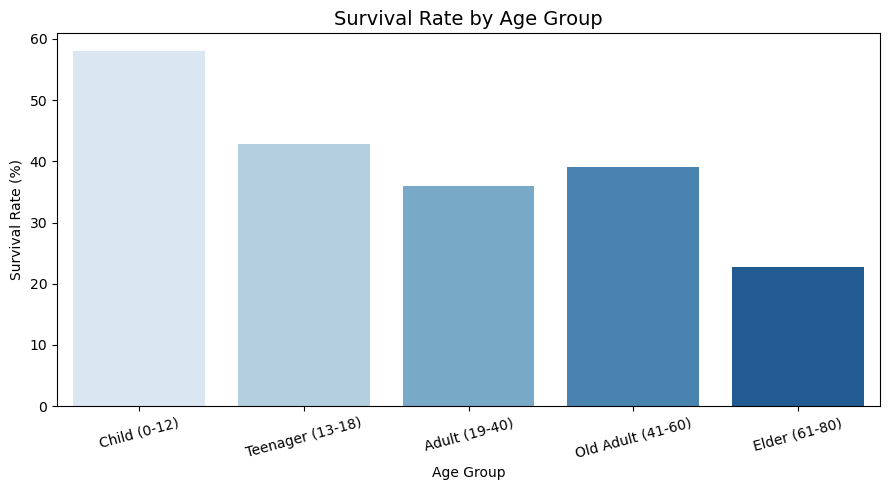

In [26]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,12,18,40,60,80],
                         labels=['Child (0-12)','Teenager (13-18)','Adult (19-40)','Old Adult (41-60)','Elder (61-80)'])

survival_by_agegroup = (
    df.groupby('AgeGroup', observed=True)['Survived']
      .mean()
      .mul(100)
      .round(1)
      .reset_index(name='SurvivalRate')
)

print("Survival rate by age group (%):")
print(survival_by_agegroup)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=survival_by_agegroup,
    x='AgeGroup',
    y='SurvivalRate',
    hue='AgeGroup',
    palette='Blues',
    order=['Child (0-12)','Teenager (13-18)','Adult (19-40)','Old Adult (41-60)','Elder (61-80)'],
    legend=False
)

plt.title('Survival Rate by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [27]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'FareClass', 'FareClassNum', 'Sex_num', 'FamilySize', 'IsAlone', 'AgeGroup']


In [28]:
import json

# 1. Standardize travel situations to match web UI labels
def get_ui_family(row):
    if row['FamilySize'] == 1:
        return 'Alone'
    elif 2 <= row['FamilySize'] <= 4:
        return 'Small family (2-4)'
    else:
        return 'Large family (5+)'

df['UI_Family'] = df.apply(get_ui_family, axis=1)

# 2. Map age groups to match the UI categories exactly (converting to string to avoid type conflicts)
age_map = {
    'Child (0-12)': 'Child (0-12)',
    'Teenager (13-18)': 'Teen (13-18)', 
    'Teen (13-18)': 'Teen (13-18)',
    'Adult (19-40)': 'Adult (19-40)',
    'Old Adult (41-60)': 'Older adult (41-60)',
    'Older adult (41-60)': 'Older adult (41-60)',
    'Elder (61-80)': 'Elder (61-80)'
}
df['UI_AgeGroup'] = df['AgeGroup'].map(age_map).fillna(df['AgeGroup'].astype(str))

# 3. FIX: Added observed=True to eliminate ghost rows, and .dropna() to guarantee clean numbers
prob_df = df.groupby(['Sex', 'Pclass', 'UI_AgeGroup', 'UI_Family'], observed=True)['Survived'].mean().reset_index()
prob_df = prob_df.dropna(subset=['Survived'])

# 4. Calculate true historical survival rate percentages
prob_df['Survived'] = (prob_df['Survived'] * 100).round(1)

# 5. Format columns to match JavaScript lookup requirements
prob_df.columns = ['sex', 'pclass', 'ageGroup', 'familySituation', 'prob']

# 6. Output the clean data array
print(json.dumps(prob_df.to_dict(orient='records'), indent=2))

[
  {
    "sex": "female",
    "pclass": 1,
    "ageGroup": "Child (0-12)",
    "familySituation": "Small family (2-4)",
    "prob": 0.0
  },
  {
    "sex": "female",
    "pclass": 1,
    "ageGroup": "Teen (13-18)",
    "familySituation": "Alone",
    "prob": 100.0
  },
  {
    "sex": "female",
    "pclass": 1,
    "ageGroup": "Teen (13-18)",
    "familySituation": "Large family (5+)",
    "prob": 100.0
  },
  {
    "sex": "female",
    "pclass": 1,
    "ageGroup": "Teen (13-18)",
    "familySituation": "Small family (2-4)",
    "prob": 100.0
  },
  {
    "sex": "female",
    "pclass": 1,
    "ageGroup": "Adult (19-40)",
    "familySituation": "Alone",
    "prob": 100.0
  },
  {
    "sex": "female",
    "pclass": 1,
    "ageGroup": "Adult (19-40)",
    "familySituation": "Large family (5+)",
    "prob": 100.0
  },
  {
    "sex": "female",
    "pclass": 1,
    "ageGroup": "Adult (19-40)",
    "familySituation": "Small family (2-4)",
    "prob": 96.7
  },
  {
    "sex": "female",
    "pc